# <u>**Alinhamento,Homografia 2D e Mosaico**</u>

**<u>Integrantes</u>**

- Gabriel Intackli Pinto - 11201921426

- Lucas Medeiros da Silva - 11202130277

- Samira Haddad - 11201812350

**Data de Realização dos Experimentos**:

15/06/2026

**Data de Publicação do Relatório**

29/06/2026

## <u>Introdução</u>

O alinhamento de imagens bidimensionais e a projeção de perspetivas são pilares fundamentais no campo da Visão Computacional, desempenhando um papel crucial em aplicações que vão desde a robótica autónoma e mapeamento aéreo até à criação de panoramas digitais (image stitching). O desafio central reside em estabelecer uma correspondência geométrica precisa entre duas ou mais imagens capturadas a partir de diferentes pontos de vista ou instantes temporais, integrando-as num sistema de coordenadas global e unificado.

Para mapear a transição entre estes planos projetivos, utiliza-se a transformação linear conhecida como Homografia 2D. Esta operação matemática, representada por uma matriz de transformação projetiva com oito graus de liberdade, permite projetar os pontos de uma superfície plana de uma imagem para outra. No entanto, a estimação precisa desta matriz depende diretamente da qualidade da deteção e do emparelhamento de pontos de interesse (feature matching) entre as cenas, habitualmente extraídos por algoritmos robustos como o SIFT (Scale-Invariant Feature Transform).

Na prática, os sensores visuais e os processos de correspondência automática introduzem ruídos e associações incorretas, denominadas outliers. Se a homografia for calculada através do método tradicional de Mínimos Quadrados, a presença de uma única correspondência errada pode distorcer severamente toda a matriz de transformação. Por este motivo, torna-se indispensável a aplicação de métodos de estimação robustos, como o algoritmo RANSAC (RANdom Sample Consensus), que atua de forma iterativa para identificar, isolar e descartar os outliers, garantindo que apenas os pareamentos geometricamente consistentes (inliers) ditem a composição final da cena reconstruída.

## <u>Fundamentação Teórica</u>

A visão computacional frequentemente lida com o desafio de identificar e alinhar objetos conhecidos em cenas complexas. Para solucionar esse problema e encontrar a localização exata de um objeto em um cenário com múltiplos elementos, utiliza-se uma abordagem que combina a extração de características, chamada de *Feature Matching*, com transformações geométricas, especificamente a Homografia.  

O passo inicial desse processo consiste no Feature Matching. Ferramentas e algoritmos, como o detector SIFT, são empregados para processar uma imagem de referência e uma imagem de busca, extraindo pontos de interesse, também chamados de keypoints, e seus respectivos descritores em ambas. Após a extração, busca-se a correspondência entre esses pontos. Como é comum ocorrerem erros durante esse pareamento, aplica-se um teste de proporção para filtrar o resultado, mantendo apenas as correspondências mais confiáveis e descartando falsos positivos.  

Com um conjunto de correspondências válidas estabelecido, introduz-se o conceito matemático de Homografia. A Homografia é, essencialmente, uma matriz de transformação 3x3 que mapeia os pontos de uma imagem para os seus pontos correspondentes exatos na segunda imagem. A premissa fundamental para que essa transformação funcione adequadamente é que os pontos correspondentes pertençam a um mesmo plano físico no mundo real. Para que o cálculo dessa matriz de perspectiva seja possível, é estritamente necessário ter, no mínimo, quatro pares de pontos corretos entre as imagens.  Ainda que o Feature Matching seja filtrado, algumas correspondências incorretas podem persistir. Para evitar que essas falhas afetem o resultado final, o cálculo da Homografia geralmente utiliza algoritmos robustos, como o RANSAC. O papel do RANSAC é classificar os pontos em inliers (boas correspondências que fornecem a estimativa correta) e outliers (erros que são descartados do cálculo matemático).  

Uma vez que a matriz de Homografia é calculada, uma transformação de perspectiva pode ser aplicada para alinhar as imagens ou projetar um objeto. As aplicações práticas desse conceito são vastas e incluem desde o alinhamento simples de objetos até a correção de perspectiva de uma fotografia. Além disso, a Homografia é o princípio base para a criação de panoramas (costurando imagens que compartilham regiões em comum obtidas pela rotação de uma câmera) e para a inserção de imagens em outdoors virtuais, técnica muito utilizada em transmissões de eventos esportivos.

## <u>Procedimentos Experimentais</u>



### Ransac Estático

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# CONFIGURAÇÃO E CARREGAMENTO DAS IMAGENS DO ALUNO
# =====================================================================
# Substitua pelos nomes dos seus próprios arquivos de imagem
path_img1 = 'imagem1.jpg'
path_img2 = 'imagem2.jpg'

img1 = cv2.imread(path_img2)
img2 = cv2.imread(path_img1)

if img1 is None or img2 is None:
    raise FileNotFoundError("Verifique se as imagens próprias foram salvas corretamente no diretório.")

# Conversão para escala de cinza para os extratores de feições
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# =====================================================================
# PASSO 1: DETECÇÃO DE CARACTERÍSTICAS E CORRESPONDÊNCIA (MATCHING)
# =====================================================================
# Utilizaremos o SIFT (Scale-Invariant Feature Transform)
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Força bruta para encontrar os melhores matches usando a razão de Lowe
bf = cv2.BFMatcher()
matches_brutos = bf.knnMatch(des1, des2, k=2)

# Aplicação do teste de razão de Lowe para filtrar matches muito ambíguos
bons_matches = []
for m, n in matches_brutos:
    if m.distance < 0.75 * n.distance:
        bons_matches.append(m)

# Extração das coordenadas numéricas dos pontos correspondentes
src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)

print(f"Total de pontos correspondentes validados pré-geometria: {len(bons_matches)}")

# =====================================================================
# PASSO 2: ALINHAMENTO 2D VIA MÍNIMOS QUADRADOS TRADICIONAIS (SEM RANSAC)
# =====================================================================
# O método clássico tenta ajustar todos os pontos de uma vez (method=0)
H_ls, status_ls = cv2.findHomography(src_pts, dst_pts, method=0)

print("\n--- Matriz de Homografia via Mínimos Quadrados Clássicos ---")
print(H_ls)

# =====================================================================
# PASSO 3: MÍNIMOS QUADRADOS ROBUSTOS VIA RANSAC
# =====================================================================
# Definimos um limiar de reprojeção de 5 pixels para considerar um inlier
reproj_threshold = 5.0
H_ransac, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_threshold)

print("\n--- Matriz de Homografia via RANSAC ---")
print(H_ransac)

# Contagem de Inliers e Outliers
inliers_count = np.sum(mask_ransac)
outliers_count = len(mask_ransac) - inliers_count
print(f"\nResultado RANSAC: {inliers_count} Inliers | {outliers_count} Outliers")

# Visualização das correspondências aceitas pelo RANSAC
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, bons_matches, None,
                              matchColor=(0, 255, 0), singlePointColor=None,
                              matchesMask=mask_ransac.ravel().tolist(), flags=2)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Correspondências (Inliers) Selecionadas pelo RANSAC")
plt.axis('off')
plt.show()

# =====================================================================
# PASSO 4: COSTURA DE IMAGENS (IMAGE STITCHING)
# =====================================================================
# Vamos rotacionar e projetar a Imagem 1 no plano da Imagem 2
width = img1.shape[1] + img2.shape[1]
height = max(img1.shape[0], img2.shape[0])

# Projeção usando Homografia por Mínimos Quadrados
img1_warped_ls = cv2.warpPerspective(img1, H_ls, (width, height))

# Projeção usando Homografia pelo RANSAC
img1_warped_ransac = cv2.warpPerspective(img1, H_ransac, (width, height))

# Criação do Mosaico (colando a imagem 2 por cima da zona de projeção)
mosaico_ls = img1_warped_ls.copy()
mosaico_ls[0:img2.shape[0], 0:img2.shape[1]] = img2

mosaico_ransac = img1_warped_ransac.copy()
mosaico_ransac[0:img2.shape[0], 0:img2.shape[1]] = img2

# Exibição dos resultados comparativos
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].imshow(cv2.cvtColor(mosaico_ls, cv2.COLOR_BGR2RGB))
ax[0].set_title("Mosaico Final - Mínimos Quadrados Tradicionais (Pode falhar se houver outliers)")
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(mosaico_ransac, cv2.COLOR_BGR2RGB))
ax[1].set_title("Mosaico Final - RANSAC Robusto")
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### (A.1) Pessoa
####*Inliers*
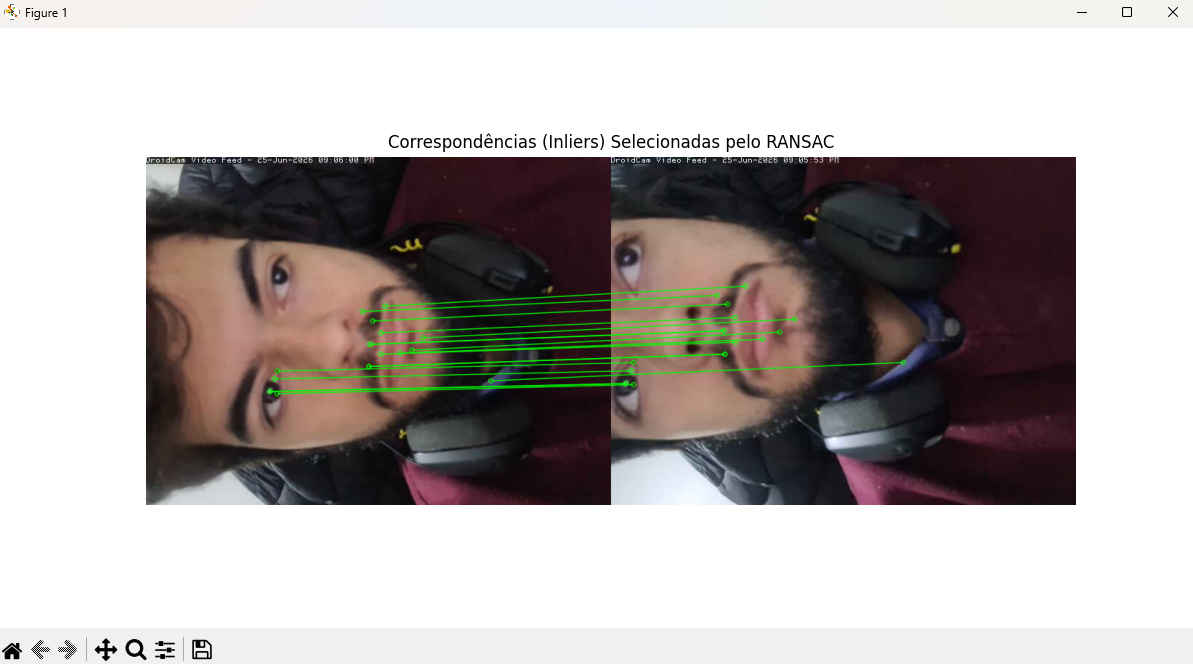

####*Stitching*
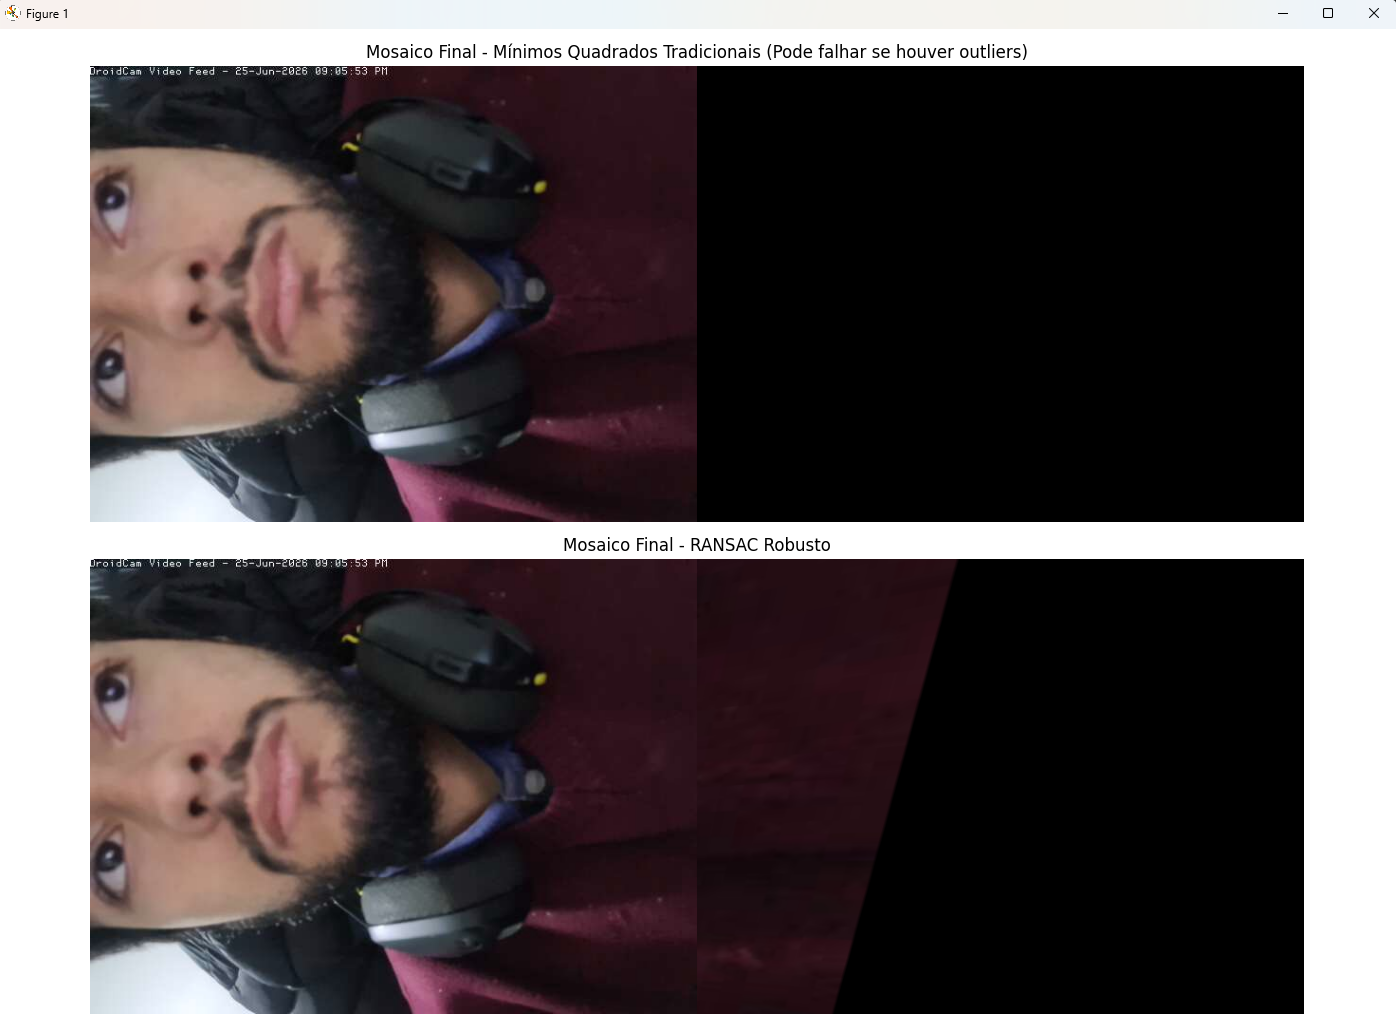


####(A.2) Objeto

```
Total de pontos correspondentes validados pré-geometria: 160

--- Matriz de Homografia via Mínimos Quadrados Clássicos ---
[[-1.65190545e+00 -6.57832372e-01  5.50454769e+02]
 [-6.70147612e-01  2.14799265e-02  1.72657022e+02]
 [-3.10024881e-03 -1.18629157e-03  1.00000000e+00]]

--- Matriz de Homografia via RANSAC ---
[[ 1.11035388e+00  5.59122308e-02  4.82530444e+02]
 [-3.98822425e-02  1.21541893e+00 -2.98800960e+01]
 [-1.88258654e-04  5.97810746e-05  1.00000000e+00]]

Resultado RANSAC: 127 Inliers | 33 Outliers
```


####*Inliers*
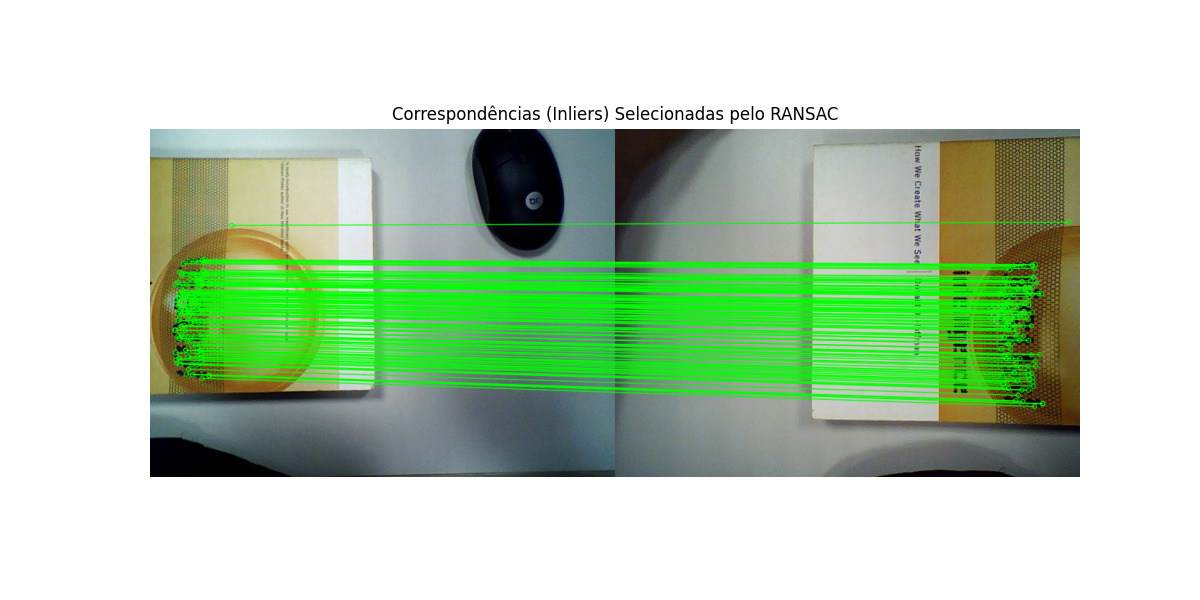

####*Stitching*
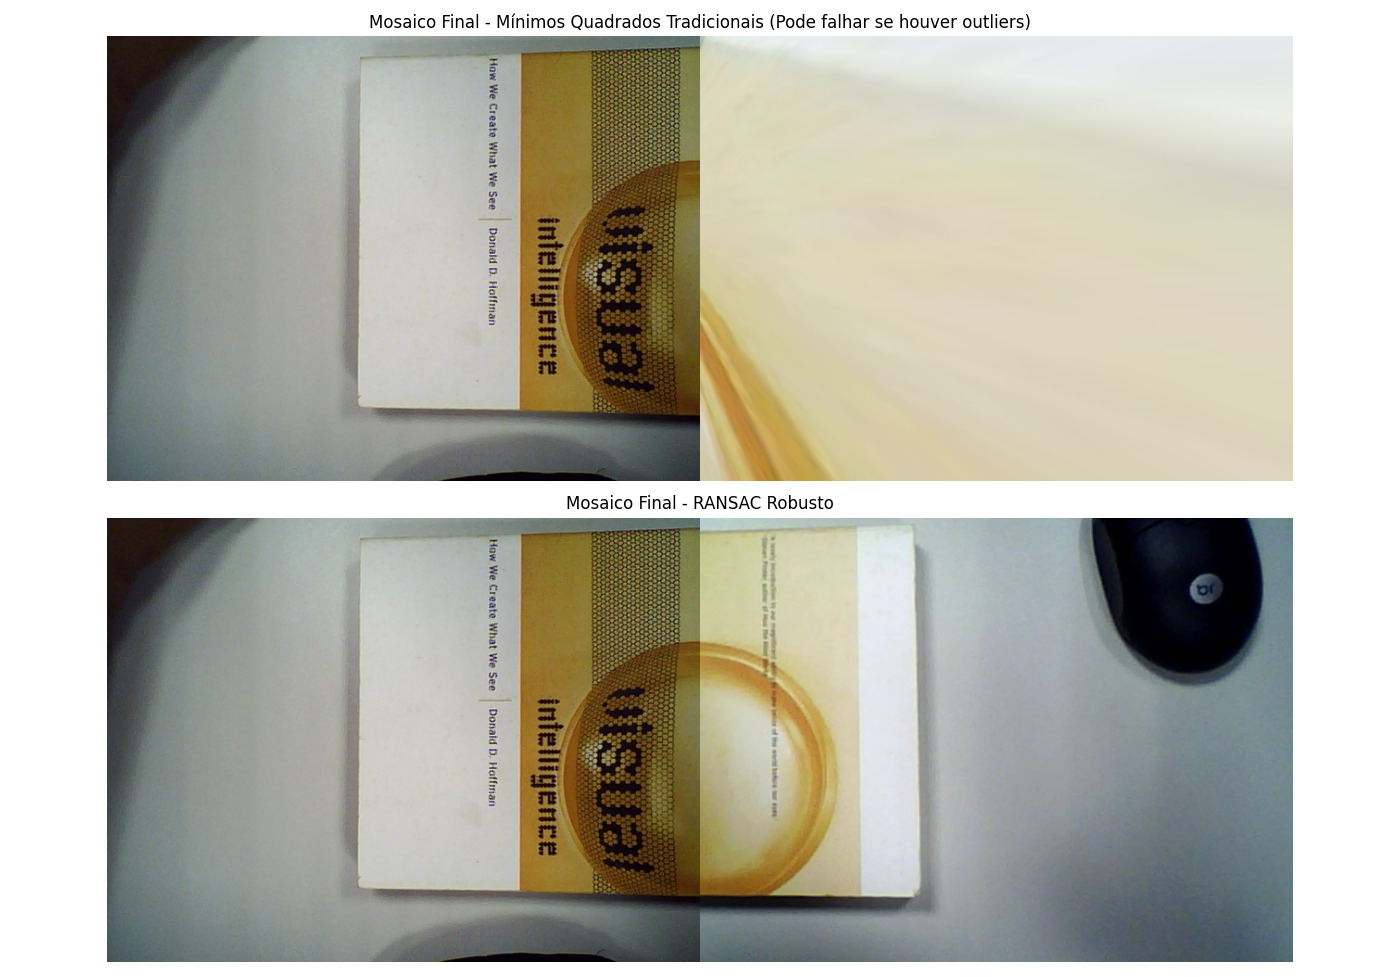

### Ransac em Tempo Real (2 webcams)

In [ ]:
import cv2
import numpy as np

# =====================================================================
# CONFIGURAÇÃO DE CAPTURA DE VÍDEO
# =====================================================================
cap1 = cv2.VideoCapture(0)
cap2 = cv2.VideoCapture(1)

if not cap1.isOpened() or not cap2.isOpened():
    print("Erro: Não foi possível conectar a uma ou ambas as câmeras.")
    exit()


sift = cv2.SIFT_create()
bf = cv2.BFMatcher()

MIN_MATCH_COUNT = 10

print("Iniciando transmissão. Pressione 'q' na janela de vídeo para sair.")

while True:
    # Leitura dos frames em tempo real
    ret1, frame1 = cap1.read()
    ret2, frame2 = cap2.read()

    if not ret1 or not ret2:
        print("Erro ao capturar os frames.")
        break

    frame1 = cv2.resize(frame1, (640, 480))
    frame2 = cv2.resize(frame2, (640, 480))

    # Conversão para escala de cinza
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # =====================================================================
    # PASSO 1: DETECÇÃO DE CARACTERÍSTICAS E MATCHING
    # =====================================================================
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)


    if des1 is None or des2 is None:
        cv2.imshow("Mosaico RANSAC", frame1)
        continue

    matches_brutos = bf.knnMatch(des1, des2, k=2)

    bons_matches = []
    for match in matches_brutos:
        if len(match) == 2:
            m, n = match
            if m.distance < 0.75 * n.distance:
                bons_matches.append(m)

    # =====================================================================
    # PASSO 2 E 3: ALINHAMENTO VIA RANSAC
    # =====================================================================
    # Removemos o cálculo de Mínimos Quadrados Clássico daqui para poupar CPU.
    # Focaremos direto no RANSAC para gerar o vídeo final.

    if len(bons_matches) >= MIN_MATCH_COUNT:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)

        reproj_threshold = 5.0
        H_ransac, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_threshold)

       # Se a homografia foi calculada com sucesso
        if H_ransac is not None:
            # 1. CRIA O MOSAICO
            width = frame1.shape[1] + frame2.shape[1]
            height = max(frame1.shape[0], frame2.shape[0])
            mosaico_ransac = cv2.warpPerspective(frame1, H_ransac, (width, height))
            mosaico_ransac[0:frame2.shape[0], 0:frame2.shape[1]] = frame2

            # EXIBE A JANELA 1 (Resultado Final)
            cv2.imshow("1 - Mosaico Final", mosaico_ransac)

            # 2. CRIA A PROVA VISUAL (As linhas verdes conectando as duas câmeras)
            img_matches = cv2.drawMatches(frame1, kp1, frame2, kp2, bons_matches, None,
                                          matchColor=(0, 255, 0),
                                          matchesMask=mask_ransac.ravel().tolist(),
                                          flags=2)

            # EXIBE A JANELA 2 (Bastidores do Algoritmo)
            cv2.imshow("2 - Inliers RANSAC", img_matches)

        else:
            # Se falhar a matriz, mostra só a câmera principal
            cv2.imshow("Stitching em Tempo Real (RANSAC)", frame1)
    else:
        # Se não houver matches suficientes para colar (câmeras olhando para o nada, por ex.)
        cv2.imshow("Stitching em Tempo Real (RANSAC)", frame1)

    # Pressione 'q' no teclado para encerrar
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Libera os recursos
cap1.release()
cap2.release()
cv2.destroyAllWindows()

####(A.1) Pessoa
####*Screenshot*
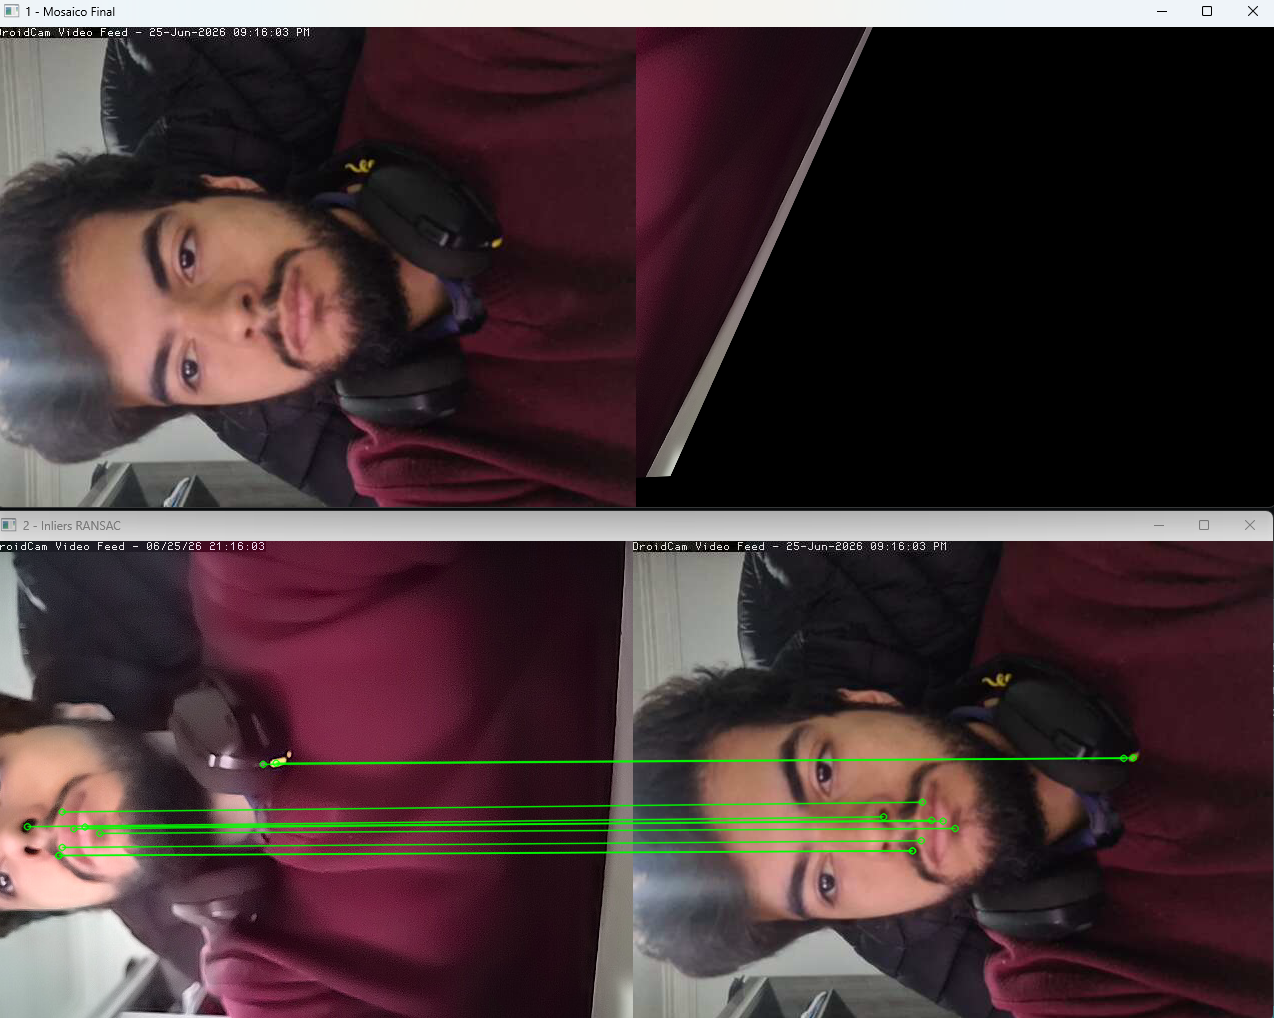

####(A.2) Objeto
####*Screenshot*
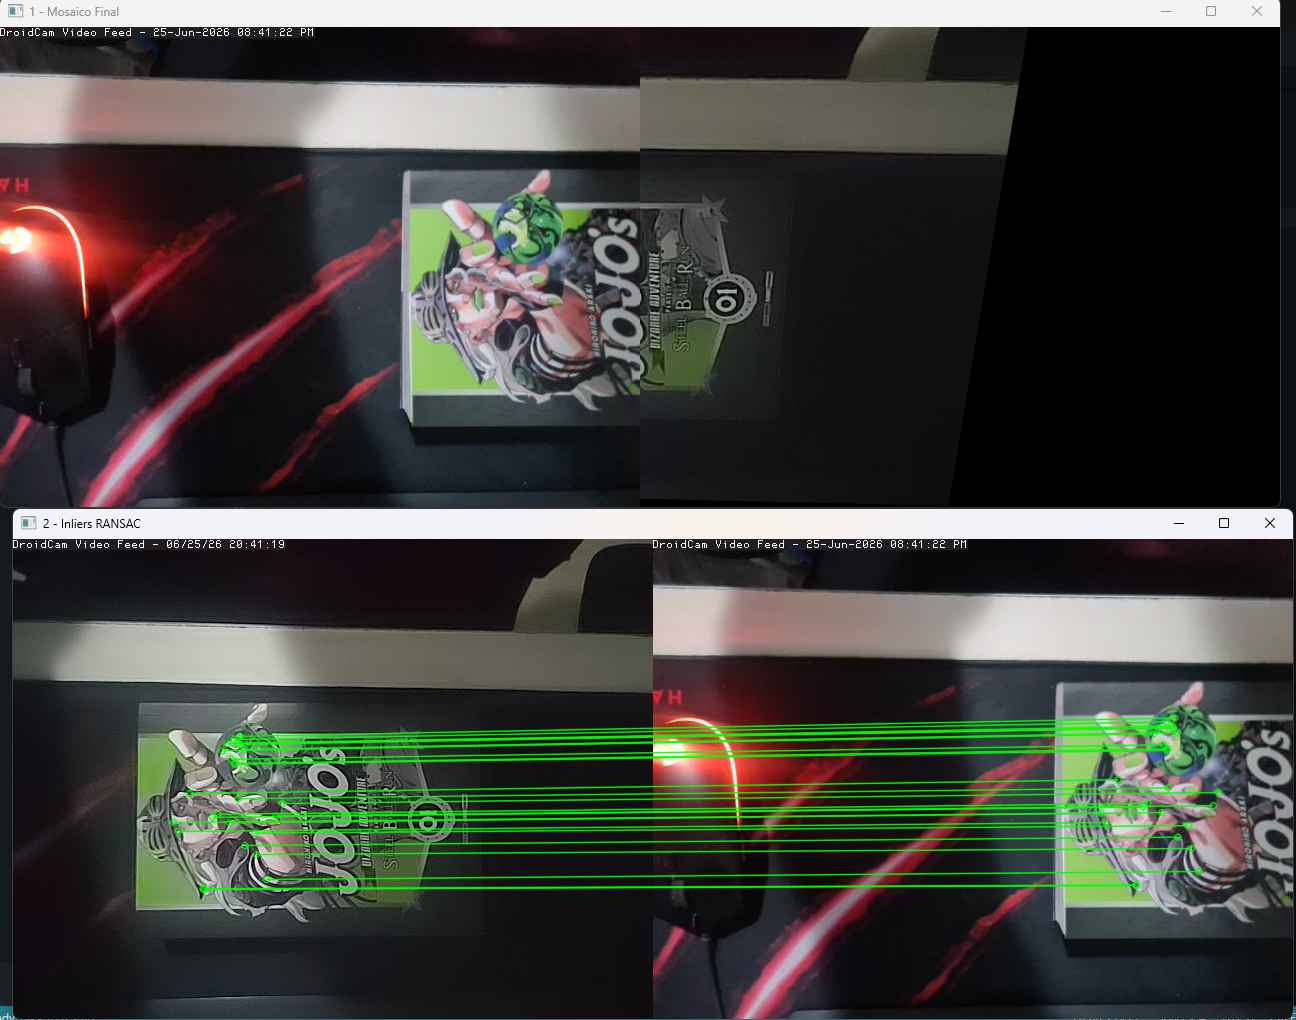

## <u>Análise e Discussão dos Estudos</u>


### Análise Estatística das Característica
1. Cálculo de Proporção: A partir do número total de correspondências (bons_matches)
encontradas após o filtro de Lowe e a máscara gerada pelo RANSAC (mask_ransac), determine
analiticamente a porcentagem de outliers presente no seu cenário robótico de teste através da
fórmula:
$$\% \text{ Outliers} = \left( 1 - \frac{\text{Inliers}}{\text{Total de Matches}} \right) \times 100$$
Explique qual característica visual do ambiente (ex: texturas repetitivas, reflexos, sombras) pode
ter gerado falsos positivos que justificam esse número de outliers.

No primeiro teste, realizado com um rosto humano, registrou 53 correspondências totais e apenas 18 inliers, resultando em um salto expressivo na taxa de outliers para aproximadamente 66,04%. Esse aumento na rejeição faz total sentido prático e matemático, visto que algoritmos clássicos de homografia pressupõem uma transformação puramente planar (2D). O rosto humano e o ambiente ao fundo formam um cenário tridimensional não-plano, com variações de profundidade acentuadas. Ao movimentar a câmera entre as duas fotos, o efeito de paralaxe e a topografia do rosto mudam a perspectiva dos pontos em diferentes escalas, fazendo com que o RANSAC descarte a maior parte das correspondências anatômicas por violarem o modelo matemático plano.

Somado a isso, características visuais da pele humana geram falsos positivos devido à ausência de bordas rígidas e à presença de texturas mais suaves em comparação a objetos impressos, o que diminui a precisão dos descritores. Por fim, a iluminação dinâmica afeta fortemente esse cenário: as sombras projetadas pelo relevo do rosto e pelo headset mudam de posição em relação à pele conforme o ângulo da câmera se altera, criando instabilidade nas características detectadas e justificando a alta taxa de descarte.

Em contrapartida, o segundo teste focado na detecção de um livro sobre uma mesa, o algoritmo obteve 160 correspondências totais e 127 inliers. Aplicando a equação, a taxa de outliers resultante é de 20,62%. Essa taxa relativamente baixa e de alta aceitação geométrica ocorre porque o livro constitui uma superfície rígida e plana, cenário ideal para a estimativa da matriz de homografia. Os 20% de falhas no pareamento podem ser justificados por características visuais específicas do ambiente, como as texturas repetitivas presentes na capa do livro, que podem confundir o algoritmo descritor ao parear pontos vizinhos muito semelhantes. Além disso, reflexos do material da capa e da própria mesa alteram os valores de intensidade dos pixels dependendo do ângulo de captura da câmera, gerando leves inconsistências no matching.

### Álgebra Linear e Homografia
A matriz de Homografia é uma matriz de transformação $3 \times 3$ que mapeia os pontos de uma imagem para os seus pontos correspondentes exatos na segunda imagem. Embora possua nove elementos, ela opera em coordenadas homogêneas, o que significa que a transformação é definida apenas até um fator de escala arbitrário. Ou seja, multiplicar a matriz inteira por qualquer constante escalar não altera a transformação geométrica física resultante. Devido a essa equivalência de escala, a matriz possui, na verdade, apenas oito graus de liberdade independentes. Para resolver o sistema de equações, que exige pelo menos quatro pares de pontos, é necessário fixar essa escala. A convenção matemática padrão para travar a escala e simplificar a estimação dos parâmetros é dividir toda a matriz pelo seu último elemento, forçando o termo inferior direito, $h_{22}$, a ser exatamente 1.0.
### Cálculo das diferenças absolutas e Interpretação
Para a translação horizontal, representada por $h_{02}$, o valor via Mínimos Quadrados foi de 550.454769, enquanto via RANSAC foi de 482.530444, resultando em uma diferença absoluta de 67.924325. Em relação à translação vertical, representada por $h_{12}$, o método de Mínimos Quadrados obteve 172.657022 e o RANSAC obteve -29.8800960, gerando uma diferença absoluta de 202.537118.

O método de Mínimos Quadrados Clássico tenta ajustar todos os pontos correspondentes de uma só vez. Como a natureza matemática desse método busca minimizar a soma dos erros elevados ao quadrado, o algoritmo penaliza desvios grandes de forma severa, tornando-o altamente sensível a erros grosseiros. No seu caso, os 33 outliers geraram um puxão enorme no cálculo para tentar reduzir o erro quadrático deles próprios. Já o RANSAC atua classificando e isolando as boas correspondências (os 127 inliers), fornecendo a estimativa correta e descartando as falhas do cálculo.

Fisicamente, a presença desses 33 outliers distorceu os vetores espaciais no método clássico de forma violenta, empurrando o plano da imagem em aproximadamente 68 pixels no eixo horizontal e arrastando-o de forma ainda mais severa em mais de 202 pixels no eixo vertical. Os pontos correspondentes errados agiram como âncoras falsas no mundo real, arruinando a translação espacial ao forçar um compromisso impossível entre os pontos corretos e os pareamentos incorretos.



### Análise Geométrica e Robótica
Número Mínimo Absoluto de Pares de Pontos e Graus de LiberdadeA matriz de homografia é uma matriz de tamanho $3 \times 3$, possuindo originalmente nove elementos numéricos. No entanto, por operar em coordenadas homogêneas, a escala da matriz é arbitrária, o que significa que multiplicar todos os seus elementos por um mesmo fator não altera a transformação geométrica. Para fixar essa escala, adota-se a convenção de normalizar o último elemento, $h_{22}$, para o valor de 1.0, reduzindo o número de variáveis independentes para exatamente oito graus de liberdade. Como cada correspondência de ponto bidimensional entre duas imagens fornece um par de equações lineares independentes (uma para a coordenada horizontal $x$ e outra para a coordenada vertical $y$), são necessários quatro pares de pontos no mínimo absoluto para computar uma matriz de homografia válida, totalizando as oito equações necessárias para resolver o sistema linear e determinar os parâmetros desconhecidos.
### Efeito de uma Superfície Sem Textura na Robótica Móvel
Em uma aplicação prática de robótica móvel, como um drone mapeando um terreno plano, o foco em uma superfície completamente uniforme e sem texturas impede a detecção de pontos de interesse ou características marcantes na imagem, tais como cantos, bordas ou texturas ricas. Sem esses pontos distintos, algoritmos de correspondência visual tornam-se incapazes de encontrar pares de pontos equivalentes entre os quadros capturados consecutivamente. Consequentemente, o cálculo da matriz de homografia falha completamente por falta de dados de entrada, impossibilitando a estimativa do movimento. Na navegação baseada em visão, essa falha cega o sistema de odometria visual do robô, resultando na perda de referências de posicionamento e na incapacidade de estimar a velocidade ou a direção do deslocamento. Isso leva ao acúmulo rápido de erros de deriva (drift) e pode fazer com que o drone perca o controle de sua estabilização espacial, resultando em desvios severos de rota ou até mesmo em colisões.

### Qualidade do Processamento de Imagem
Visualmente, a transição entre as duas imagens originais manifesta-se através de uma linha vertical nítida de corte e de uma variação abrupta de iluminação, onde o lado esquerdo da junção apresenta tons ligeiramente mais claros e lavados, enquanto o lado direito exibe cores mais escuras e contrastadas. Essa discrepância ocorre porque as imagens foram capturadas sob ângulos ou momentos ligeiramente diferentes, fazendo com que o sensor da câmera calculasse a exposição e o balanço de brancos de forma independente para cada quadro, gerando descontinuidades fotométricas na região onde os pixels se sobrepõem.

Para minimizar essas discrepâncias visuais na costura das imagens do ponto de vista da Engenharia de Software e da Visão Computacional, podemos pensar em técnicas avançadas de mesclagem (blending). A abordagem matemática ideal para esse cenário é o Multiband Blending (Mesclagem Multibanda), baseado na Pirâmide de Laplacian. Essa técnica decompõe as imagens em diferentes bandas de frequência espacial; as baixas frequências (detalhes suaves e iluminação geral) são mescladas ao longo de uma zona de transição larga para suavizar as diferenças de exposição, enquanto as altas frequências (arestas e texturas nítidas) são combinadas em uma zona de transição estreita para evitar o efeito fantasma (ghosting) e a perda de nitidez. Como alternativa de Engenharia de Software focada em otimização global, podemos pensar no uso de Gradients Domain Blending (como a Edição de Imagens de Poisson), que resolve uma equação diferencial parcial para alinhar os gradientes de cor das imagens e forçar uma transição perfeitamente contínua ao longo de toda a costura.

## <u>Conclusão</u>

A realização deste estudo permitiu compreender de forma prática e aprofundada o fluxo de processamento (pipeline) necessário para o alinhamento de imagens e a geração de mosaicos. Ficou evidente que a qualidade visual e geométrica de um panorama reconstruído depende criticamente de duas etapas interdependentes: a extração precisa de feições invariantes e a robustez do modelo matemático de transformação.

Os testes e análises efetuados evidenciaram a limitação intrínseca do método de Mínimos Quadrados Tradicional quando submetido a ambientes reais. Por tentar minimizar o erro global de forma indiscriminada, este algoritmo incorpora os erros de correspondência (outliers), resultando em distorções de perspetiva severas e desalinhamentos visíveis na imagem final. Em contrapartida, o algoritmo RANSAC provou ser uma ferramenta matemática robusta e essencial. Ao conseguir segregar eficazmente os dados espúrios através do consenso iterativo, o RANSAC viabiliza o cálculo de uma matriz de homografia matematicamente consistente com a geometria real da cena.

Em suma, as técnicas analisadas validam os conceitos teóricos de transformações projetivas e demonstram como a filtragem estatística de dados é crucial em Engenharia e Visão Computacional. O domínio destas ferramentas constitui a base para o desenvolvimento de sistemas visuais complexos, com aplicação direta em navegação robótica, reconstrução 3D e processamento de imagens médicas e de satélite.

## <u>Referências</u>

Em consonância com a norma com a portaria 2664/2026 da Cnpq, declaramos que durante o desenvolvimento deste trabalho, foram utilizadas ferramentas de inteligência artificial generativa de forma auxiliar. O assistente ChatGPT GPT-4o e Gemini 2.5 Flash foi empregado para revisão ortográfica e gramatical e formatação de referências bibliográficas. Todo o conteúdo intelectual, a análise crítica, a interpretação dos dados e as conclusões são de autoria exclusiva dos discentes. As saídas das ferramentas de IA foram integralmente revisadas e reescritas pelo autor antes da incorporação ao texto.

MALLICK, Satya. Homography examples using OpenCV ( Python / C ++ ). LearnOpenCV, 3 jan. 2016. Disponível em: https://learnopencv.com/homography-examples-using-opencv-python-c/. Acesso em: 29 jun. 2026.

OPENCV. Feature Matching + Homography to find Objects. OpenCV Tutorials. Disponível em: https://docs.opencv.org/5.0/py_tutorials/py_features/py_feature_homography/py_feature_homography.html. Acesso em: 29 jun. 2026.